### Importing Libraries

In [9]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
import warnings
from scipy.stats.mstats import winsorize
warnings.filterwarnings('ignore')
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option('display.max_rows', None)        # None = no limit
pd.set_option('display.max_columns', None)     # None = no limit


### Load Data

In [105]:
df = pd.read_csv('weatherAUS.csv')

df['ID'] = range(1, len(df) + 1)  # 1-based indexing


df.shape

(145460, 24)

In [106]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,ID
0,2008-12-01,Albury,13.40,22.90,0.60,NaN,NaN,W,44.00,W,WNW,20.00,24.00,71.00,22.00,1007.70,1007.10,8.00,NaN,16.90,21.80,No,No,1
1,2008-12-02,Albury,7.40,25.10,0.00,NaN,NaN,WNW,44.00,NNW,WSW,4.00,22.00,44.00,25.00,1010.60,1007.80,NaN,NaN,17.20,24.30,No,No,2
2,2008-12-03,Albury,12.90,25.70,0.00,NaN,NaN,WSW,46.00,W,WSW,19.00,26.00,38.00,30.00,1007.60,1008.70,NaN,2.00,21.00,23.20,No,No,3
3,2008-12-04,Albury,9.20,28.00,0.00,NaN,NaN,NE,24.00,SE,E,11.00,9.00,45.00,16.00,1017.60,1012.80,NaN,NaN,18.10,26.50,No,No,4
4,2008-12-05,Albury,17.50,32.30,1.00,NaN,NaN,W,41.00,ENE,NW,7.00,20.00,82.00,33.00,1010.80,1006.00,7.00,8.00,17.80,29.70,No,No,5


In [109]:
df['RainTomorrow'].value_counts()

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

In [111]:
df['RainToday'].value_counts()

RainToday
No     110319
Yes     31880
Name: count, dtype: int64

In [113]:
pd.pivot_table(data=df,columns='RainTomorrow',index='RainToday',values='Date',aggfunc='count')

RainTomorrow,No,Yes
RainToday,,
No,92728,16604
Yes,16858,14597


array([[<Axes: title={'center': 'MinTemp'}>,
        <Axes: title={'center': 'MaxTemp'}>,
        <Axes: title={'center': 'Rainfall'}>,
        <Axes: title={'center': 'Evaporation'}>],
       [<Axes: title={'center': 'Sunshine'}>,
        <Axes: title={'center': 'WindGustSpeed'}>,
        <Axes: title={'center': 'WindSpeed9am'}>,
        <Axes: title={'center': 'WindSpeed3pm'}>],
       [<Axes: title={'center': 'Humidity9am'}>,
        <Axes: title={'center': 'Humidity3pm'}>,
        <Axes: title={'center': 'Pressure9am'}>,
        <Axes: title={'center': 'Pressure3pm'}>],
       [<Axes: title={'center': 'Cloud9am'}>,
        <Axes: title={'center': 'Cloud3pm'}>,
        <Axes: title={'center': 'Temp9am'}>,
        <Axes: title={'center': 'Temp3pm'}>],
       [<Axes: title={'center': 'ID'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

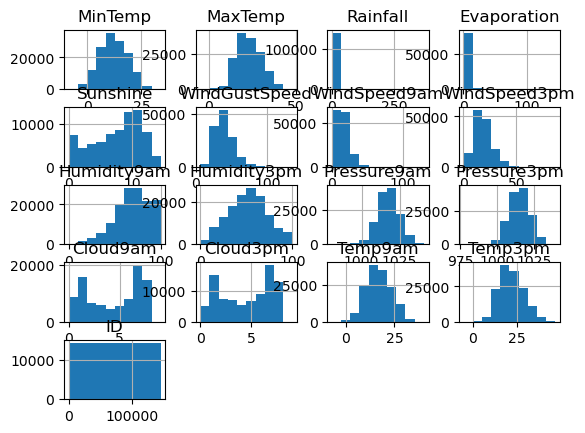

In [115]:
df.hist()

In [116]:
df.drop(columns=['RainToday','Date','Location','Rainfall'],inplace=True)

In [117]:
# df['Rainfall'].describe()

In [118]:
df.isna().sum()*100/df.shape[0]

MinTemp          1.02
MaxTemp          0.87
Evaporation     43.17
Sunshine        48.01
WindGustDir      7.10
WindGustSpeed    7.06
WindDir9am       7.26
WindDir3pm       2.91
WindSpeed9am     1.21
WindSpeed3pm     2.11
Humidity9am      1.82
Humidity3pm      3.10
Pressure9am     10.36
Pressure3pm     10.33
Cloud9am        38.42
Cloud3pm        40.81
Temp9am          1.21
Temp3pm          2.48
RainTomorrow     2.25
ID               0.00
dtype: float64

In [119]:
df.drop(columns=['Cloud3pm','Cloud9am','Sunshine','Evaporation'],inplace=True)

In [125]:
df.shape

(145460, 16)

In [127]:
print(df['RainTomorrow'].value_counts())

print()
print(df['RainTomorrow'].value_counts(normalize=True))

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

RainTomorrow
No    0.78
Yes   0.22
Name: proportion, dtype: float64


In [129]:
## out of time base
# Random sample of 10000 rows
print('OG Base :',df.shape)
oot = df.sample(n=10000, random_state=42)  # random_state for reproducibility
print('Left out base :',oot.shape)

df = df[~df['ID'].isin(oot['ID'])]

print('new Base :',df.shape)

OG Base : (145460, 16)
Left out base : (10000, 16)
new Base : (135460, 16)


In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 135460 entries, 1 to 145459
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   MinTemp        134078 non-null  float64
 1   MaxTemp        134286 non-null  float64
 2   WindGustDir    125853 non-null  object 
 3   WindGustSpeed  125914 non-null  float64
 4   WindDir9am     125631 non-null  object 
 5   WindDir3pm     131518 non-null  object 
 6   WindSpeed9am   133817 non-null  float64
 7   WindSpeed3pm   132599 non-null  float64
 8   Humidity9am    132994 non-null  float64
 9   Humidity3pm    131254 non-null  float64
 10  Pressure9am    121425 non-null  float64
 11  Pressure3pm    121450 non-null  float64
 12  Temp9am        133823 non-null  float64
 13  Temp3pm        132091 non-null  float64
 14  RainTomorrow   132412 non-null  object 
 15  ID             135460 non-null  int64  
dtypes: float64(11), int64(1), object(4)
memory usage: 17.6+ MB


In [133]:
df['WindDir3pm'].value_counts()

WindDir3pm
SE     10105
W       9405
S       9234
WSW     8867
SSE     8774
SW      8716
N       8297
WNW     8277
NW      7990
E       7899
ESE     7884
NE      7699
SSW     7598
ENE     7338
NNW     7297
NNE     6138
Name: count, dtype: int64

In [137]:
df['WindDir9am'].value_counts()

WindDir9am
N      10961
SE      8666
E       8533
SSE     8436
NW      8109
S       8055
W       7900
SW      7819
NNE     7547
NNW     7460
ENE     7290
NE      7164
ESE     7107
SSW     7063
WNW     6937
WSW     6584
Name: count, dtype: int64

In [139]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['WindGustDir'] = le.fit_transform(df['WindGustDir'])
df['WindDir9am'] = le.fit_transform(df['WindDir9am'])
df['WindDir3pm'] = le.fit_transform(df['WindDir3pm'])

In [141]:
for col in ['MinTemp','MaxTemp','WindGustDir','WindGustSpeed','WindDir9am','WindDir3pm','WindSpeed9am','WindSpeed3pm','Humidity9am','Humidity3pm','Pressure9am','Pressure3pm','Temp9am','Temp3pm']:
    df[col] = winsorize(df[col], limits=[0.01, 0.01])
    print(col,": Winsorized")

MinTemp : Winsorized
MaxTemp : Winsorized
WindGustDir : Winsorized
WindGustSpeed : Winsorized
WindDir9am : Winsorized
WindDir3pm : Winsorized
WindSpeed9am : Winsorized
WindSpeed3pm : Winsorized
Humidity9am : Winsorized
Humidity3pm : Winsorized
Pressure9am : Winsorized
Pressure3pm : Winsorized
Temp9am : Winsorized
Temp3pm : Winsorized


array([[<Axes: title={'center': 'MinTemp'}>,
        <Axes: title={'center': 'MaxTemp'}>,
        <Axes: title={'center': 'WindGustDir'}>,
        <Axes: title={'center': 'WindGustSpeed'}>],
       [<Axes: title={'center': 'WindDir9am'}>,
        <Axes: title={'center': 'WindDir3pm'}>,
        <Axes: title={'center': 'WindSpeed9am'}>,
        <Axes: title={'center': 'WindSpeed3pm'}>],
       [<Axes: title={'center': 'Humidity9am'}>,
        <Axes: title={'center': 'Humidity3pm'}>,
        <Axes: title={'center': 'Pressure9am'}>,
        <Axes: title={'center': 'Pressure3pm'}>],
       [<Axes: title={'center': 'Temp9am'}>,
        <Axes: title={'center': 'Temp3pm'}>,
        <Axes: title={'center': 'ID'}>, <Axes: >]], dtype=object)

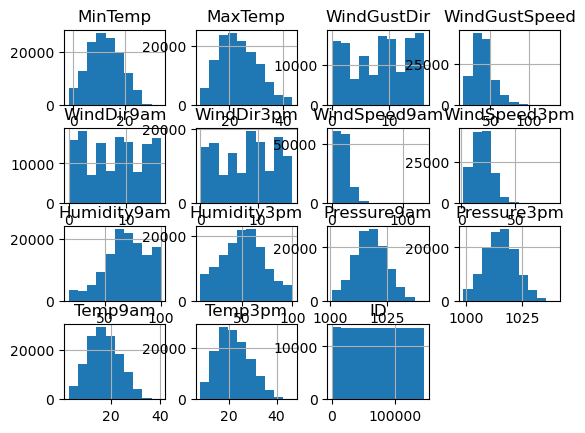

In [143]:
df.hist()

In [154]:
df.isna().sum()

MinTemp          0
MaxTemp          0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
RainTomorrow     0
ID               0
dtype: int64

In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 135460 entries, 1 to 145459
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   MinTemp        135460 non-null  float64
 1   MaxTemp        135460 non-null  float64
 2   WindGustDir    135460 non-null  int32  
 3   WindGustSpeed  135460 non-null  float64
 4   WindDir9am     135460 non-null  int32  
 5   WindDir3pm     135460 non-null  int32  
 6   WindSpeed9am   135460 non-null  float64
 7   WindSpeed3pm   135460 non-null  float64
 8   Humidity9am    135460 non-null  float64
 9   Humidity3pm    135460 non-null  float64
 10  Pressure9am    135460 non-null  float64
 11  Pressure3pm    135460 non-null  float64
 12  Temp9am        135460 non-null  float64
 13  Temp3pm        135460 non-null  float64
 14  RainTomorrow   135460 non-null  object 
 15  ID             135460 non-null  int64  
dtypes: float64(11), int32(3), int64(1), object(1)
memory usage: 16.0+ MB


In [152]:
df.fillna(0,inplace=True)

In [164]:
df['RainTomorrow'].value_counts()

RainTomorrow
0    105811
1     29649
Name: count, dtype: int64

In [162]:
df['RainTomorrow'] = np.where(df['RainTomorrow']=='Yes',1,0)

### Feature Importance

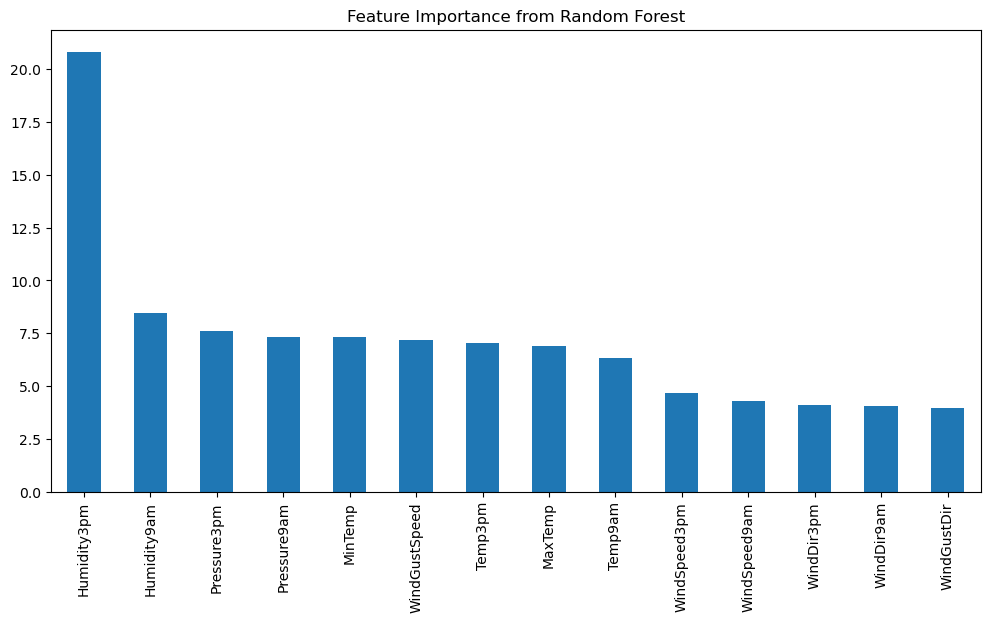

In [166]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df.drop(['RainTomorrow','ID'], axis=1)
y = df['RainTomorrow']

X = pd.get_dummies(X, drop_first=True)  # Ensure all categorical variables are encoded

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

importances = pd.Series(model.feature_importances_*100, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(12,6))
plt.title("Feature Importance from Random Forest")
plt.show()


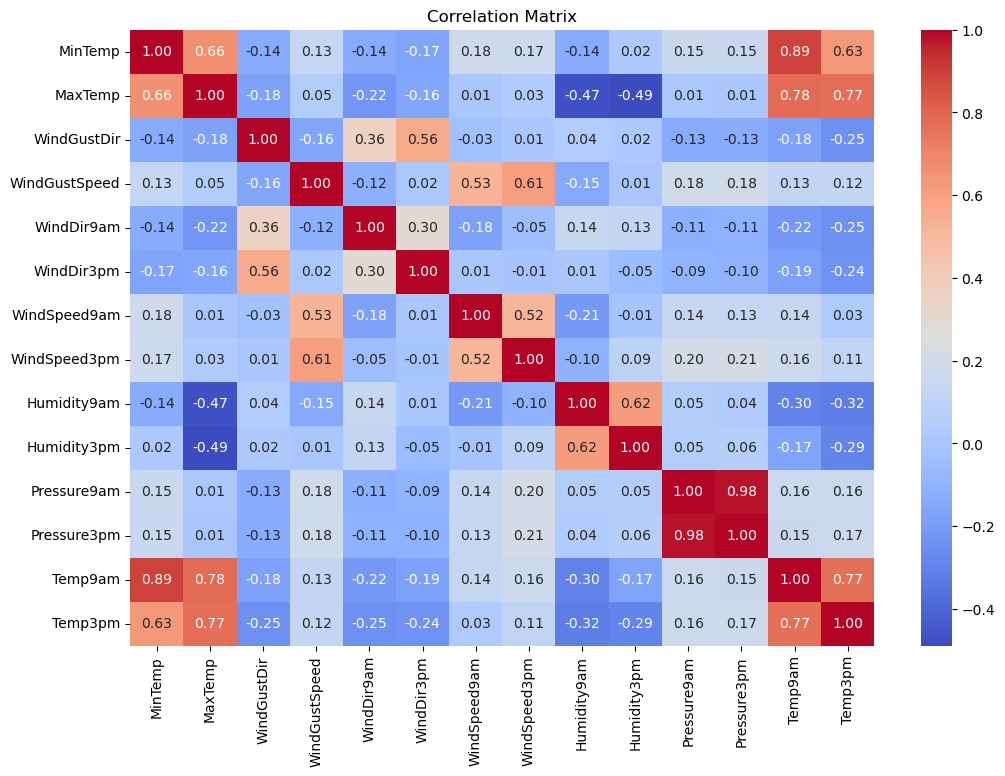

In [167]:
plt.figure(figsize=(12,8))
sns.heatmap(df.drop(columns=['RainTomorrow','ID']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


In [176]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop(columns=['RainTomorrow','ID','Pressure9am','Temp9am','Temp3pm'])
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values(by='VIF',ascending=False))


          feature   VIF
8     Humidity9am 17.20
1         MaxTemp 16.55
9     Humidity3pm 12.47
3   WindGustSpeed 11.24
0         MinTemp  9.77
10    Pressure3pm  9.53
7    WindSpeed3pm  9.32
2     WindGustDir  6.22
5      WindDir3pm  5.96
6    WindSpeed9am  5.41
4      WindDir9am  4.36


In [178]:
## Removing the ID and highly correlated columns

X = df.drop(columns=['RainTomorrow','ID','Pressure9am','Temp9am','Temp3pm'], axis=1) 
y = df['RainTomorrow'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

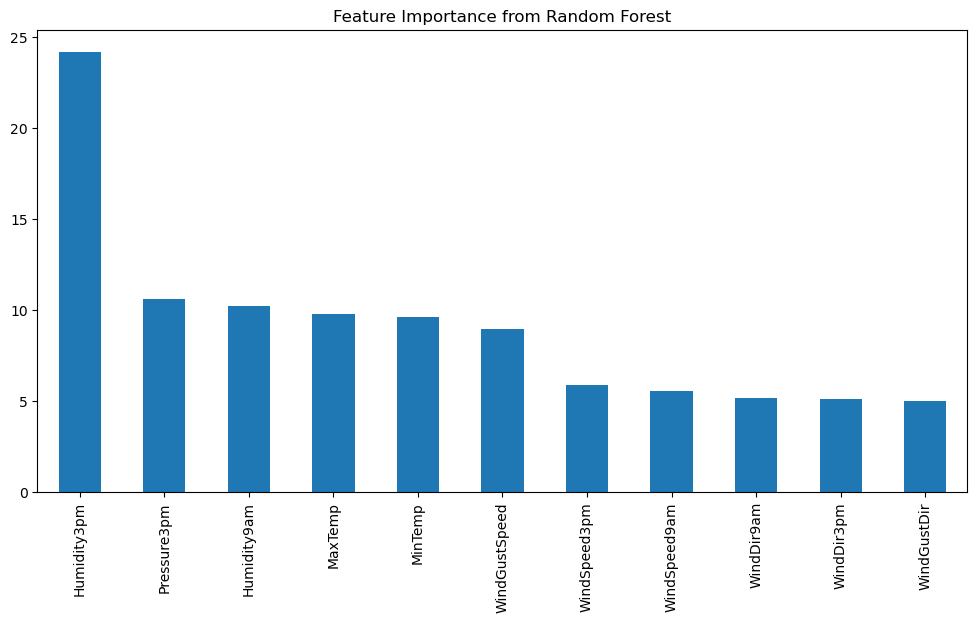

In [180]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df.drop(['RainTomorrow','ID','Pressure9am','Temp9am','Temp3pm'], axis=1)
y = df['RainTomorrow']

X = pd.get_dummies(X, drop_first=True)  # Ensure all categorical variables are encoded

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

importances = pd.Series(model.feature_importances_*100, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(12,6))
plt.title("Feature Importance from Random Forest")
plt.show()


In [196]:
neg, pos = np.bincount(y_train)  # works if binary 0/1
scale_pos_weight = neg / pos

xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric="aucpr",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

print(scale_pos_weight)
print()

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("Baseline XGBoost Accuracy:", round(accuracy_score(y_test, y_pred_xgb)*100, 2))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba_xgb)*100, 2))


3.568854196781343

Baseline XGBoost Accuracy: 80.29
ROC-AUC Score: 86.81


XGBoost Accuracy: 80.29
ROC-AUC Score: 86.81
Precision: 53.53
Recall: 75.62
F1 Score: 62.68

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.82      0.87     31743
           1       0.54      0.76      0.63      8895

    accuracy                           0.80     40638
   macro avg       0.73      0.79      0.75     40638
weighted avg       0.84      0.80      0.81     40638

Confusion Matrix:
 [[25903  5840]
 [ 2169  6726]]
PR-AUC Score: 69.29


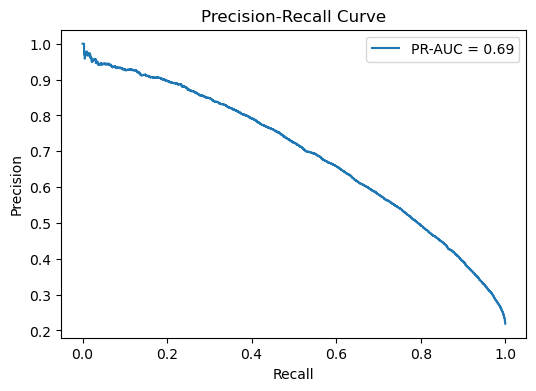

In [198]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, precision_recall_curve, auc
)
import matplotlib.pyplot as plt

# Predictions
y_pred = y_pred_xgb
y_proba = y_pred_proba_xgb

# Basic metrics
print("XGBoost Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_proba)*100, 2))
print("Precision:", round(precision_score(y_test, y_pred)*100, 2))
print("Recall:", round(recall_score(y_test, y_pred)*100, 2))
print("F1 Score:", round(f1_score(y_test, y_pred)*100, 2))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Optional: PR-AUC curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print("PR-AUC Score:", round(pr_auc*100, 2))

# Plot Precision-Recall Curve
plt.figure(figsize=(6,4))
plt.plot(recall, precision, label=f'PR-AUC = {pr_auc:.2f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


In [200]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.model_selection import train_test_split

# Split train/valid for Optuna tuning
X_train_sub, X_valid, y_train_sub, y_valid = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# Calculate scale_pos_weight = neg/pos ratio
scale_pos_weight = (y_train_sub.value_counts()[0] / y_train_sub.value_counts()[1])

def objective(trial):
    params = {
        "objective": "binary:logistic",
        "use_label_encoder": False,
        "eval_metric": "aucpr",  # Good for imbalanced classification
        "random_state": 42,
        "scale_pos_weight": scale_pos_weight,
        
        # Hyperparameters to tune
        "n_estimators": trial.suggest_int("n_estimators", 300, 1500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
    }

    model = XGBClassifier(**params)
    model.fit(X_train_sub, y_train_sub)

    preds = model.predict_proba(X_valid)[:, 1]

    # Evaluation metric: choose what matters for you
    auc = roc_auc_score(y_valid, preds)
    f1 = f1_score(y_valid, (preds > 0.5).astype(int))

    # Balance AUC and F1 (you can return only auc if that's priority)
    return 0.7 * auc + 0.3 * f1  

# Run optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best trial:")
trial = study.best_trial
print(trial.params)

# Train final model with best params
best_params = trial.params
best_params.update({
    "objective": "binary:logistic",
    "use_label_encoder": False,
    "eval_metric": "aucpr",
    "random_state": 42,
    "scale_pos_weight": scale_pos_weight,
})

best_model = XGBClassifier(**best_params)
best_model.fit(X_train, y_train)


[I 2025-09-27 16:14:29,747] A new study created in memory with name: no-name-c623cd3a-9963-45d8-b8e9-0d34f0f9da76


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-09-27 16:14:33,447] Trial 0 finished with value: 0.7917848224431904 and parameters: {'n_estimators': 526, 'max_depth': 3, 'learning_rate': 0.04606619240066405, 'subsample': 0.890762866702159, 'colsample_bytree': 0.6621311838156717, 'gamma': 2.376338796246106, 'min_child_weight': 7, 'reg_alpha': 3.6124228376922236, 'reg_lambda': 4.848859627532587}. Best is trial 0 with value: 0.7917848224431904.
[I 2025-09-27 16:14:35,590] Trial 1 finished with value: 0.7956904999324229 and parameters: {'n_estimators': 459, 'max_depth': 5, 'learning_rate': 0.1722463545825674, 'subsample': 0.8126282315813079, 'colsample_bytree': 0.7883354470695633, 'gamma': 9.282638883326479, 'min_child_weight': 6, 'reg_alpha': 4.0858293995186346, 'reg_lambda': 1.8321017413964613}. Best is trial 1 with value: 0.7956904999324229.
[I 2025-09-27 16:14:38,953] Trial 2 finished with value: 0.7979864631689961 and parameters: {'n_estimators': 410, 'max_depth': 7, 'learning_rate': 0.023145761397685698, 'subsample': 0.615

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8364732703180486, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='aucpr', feature_types=None, feature_weights=None,
              gamma=1.4269383774010018, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.013942752706007968,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=8, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1183, n_jobs=None,
              num_parallel_tree=None, ...)

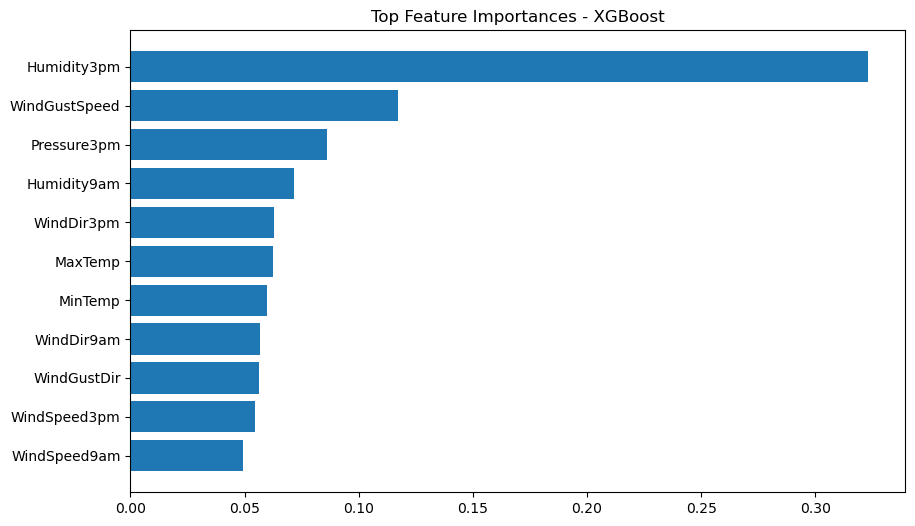

Top 5 Selected Features: ['Humidity3pm', 'WindGustSpeed', 'Pressure3pm', 'Humidity9am', 'WindDir3pm']


In [202]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance (after training your best_model)
importances = best_model.feature_importances_
features = X_train.columns

# Create a DataFrame
feat_imp = pd.DataFrame({"Feature": features, "Importance": importances})
feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

# Plot top 20
plt.figure(figsize=(10,6))
plt.barh(feat_imp["Feature"].head(20), feat_imp["Importance"].head(20))
plt.gca().invert_yaxis()
plt.title("Top Feature Importances - XGBoost")
plt.show()

# Select top 5 features
top5_features = feat_imp["Feature"].head(5).tolist()
print("Top 5 Selected Features:", top5_features)


In [208]:
y_pred_xgb = best_model.predict(X_test)
y_pred_proba_xgb = best_model.predict_proba(X_test)[:, 1]


XGBoost Accuracy: 81.61
ROC-AUC Score: 87.55
Precision: 56.01
Recall: 74.44
F1 Score: 63.92

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.84      0.88     31743
           1       0.56      0.74      0.64      8895

    accuracy                           0.82     40638
   macro avg       0.74      0.79      0.76     40638
weighted avg       0.84      0.82      0.82     40638

Confusion Matrix:
 [[26542  5201]
 [ 2274  6621]]
PR-AUC Score: 70.65


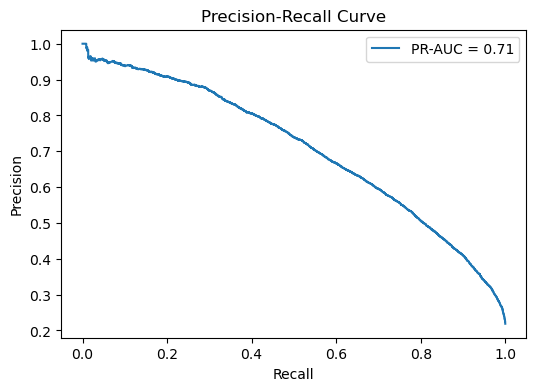

In [210]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, precision_recall_curve, auc
)
import matplotlib.pyplot as plt

# Predictions
y_pred = y_pred_xgb
y_proba = y_pred_proba_xgb

# Basic metrics
print("XGBoost Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_proba)*100, 2))
print("Precision:", round(precision_score(y_test, y_pred)*100, 2))
print("Recall:", round(recall_score(y_test, y_pred)*100, 2))
print("F1 Score:", round(f1_score(y_test, y_pred)*100, 2))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Optional: PR-AUC curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print("PR-AUC Score:", round(pr_auc*100, 2))

# Plot Precision-Recall Curve
plt.figure(figsize=(6,4))
plt.plot(recall, precision, label=f'PR-AUC = {pr_auc:.2f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


In [204]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

# Define objective function for Optuna
def objective(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 0.3),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 0.1),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 2),
        "use_label_encoder": False,
        "eval_metric": "logloss",
        "random_state": 42
    }
    
    model = XGBClassifier(**param)
    
    # 5-fold CV
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train[['Humidity3pm', 'WindGustSpeed', 'Pressure3pm', 'Humidity9am', 'WindDir3pm']], y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    return np.mean(scores)

# Create study
study = optuna.create_study(direction="maximize", study_name="XGB_Optimization")
study.optimize(objective, n_trials=30)  # adjust n_trials as needed

print("Best ROC-AUC:", study.best_value)
print("Best Hyperparameters:", study.best_params)

# ---- Train final model with best params ----
best_params = study.best_params
best_xgb = XGBClassifier(**best_params, use_label_encoder=False, eval_metric="logloss", random_state=42)
best_xgb.fit(X_train[['Humidity3pm', 'WindGustSpeed', 'Pressure3pm', 'Humidity9am', 'WindDir3pm']], y_train)

# ---- Evaluate on test set ----
y_pred = best_xgb.predict(X_test[['Humidity3pm', 'WindGustSpeed', 'Pressure3pm', 'Humidity9am', 'WindDir3pm']])
y_proba = best_xgb.predict_proba(X_test[['Humidity3pm', 'WindGustSpeed', 'Pressure3pm', 'Humidity9am', 'WindDir3pm']])[:, 1]

from sklearn.metrics import accuracy_score, roc_auc_score
print("Test Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba)*100, 2))


[I 2025-09-27 16:25:13,969] A new study created in memory with name: XGB_Optimization
[I 2025-09-27 16:25:25,307] Trial 0 finished with value: 0.8537388436911293 and parameters: {'n_estimators': 372, 'max_depth': 8, 'learning_rate': 0.04587346168738136, 'subsample': 0.9180120780392337, 'colsample_bytree': 0.8797646702651108, 'gamma': 0.05812246783711978, 'reg_alpha': 0.028103598934770702, 'reg_lambda': 1.3256642776978131}. Best is trial 0 with value: 0.8537388436911293.
[I 2025-09-27 16:25:32,932] Trial 1 finished with value: 0.855256054856086 and parameters: {'n_estimators': 288, 'max_depth': 4, 'learning_rate': 0.06844669137656231, 'subsample': 0.9722647023454208, 'colsample_bytree': 0.8793239732899558, 'gamma': 0.1561313992602487, 'reg_alpha': 0.09219826402429887, 'reg_lambda': 1.013727883499782}. Best is trial 1 with value: 0.855256054856086.
[I 2025-09-27 16:25:50,694] Trial 2 finished with value: 0.8550979503664651 and parameters: {'n_estimators': 434, 'max_depth': 9, 'learning_r

Best ROC-AUC: 0.8563632427507839
Best Hyperparameters: {'n_estimators': 376, 'max_depth': 6, 'learning_rate': 0.03985894673735213, 'subsample': 0.9062585296660876, 'colsample_bytree': 0.9575454606753745, 'gamma': 0.18634299406145155, 'reg_alpha': 0.0982819843235786, 'reg_lambda': 1.702869768134457}
Test Accuracy: 84.33
Test ROC-AUC: 85.71


Optuna XGBoost Accuracy: 84.33
ROC-AUC Score: 85.71
Precision: 71.79
Recall: 46.77
F1 Score: 56.64

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90     31743
           1       0.72      0.47      0.57      8895

    accuracy                           0.84     40638
   macro avg       0.79      0.71      0.74     40638
weighted avg       0.83      0.84      0.83     40638

Confusion Matrix:
 [[30108  1635]
 [ 4735  4160]]
PR-AUC Score: 67.28


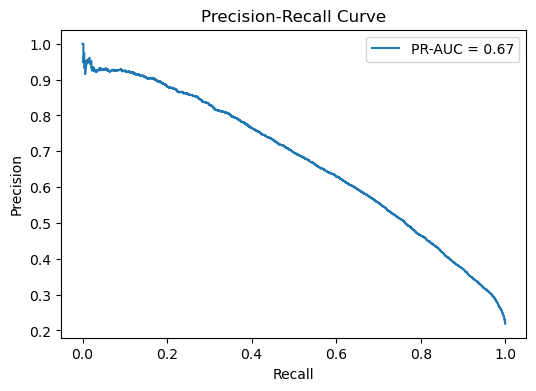

In [206]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, precision_recall_curve, auc
)
import matplotlib.pyplot as plt

# Predictions
y_pred = best_xgb.predict(X_test[['Humidity3pm', 'WindGustSpeed', 'Pressure3pm', 'Humidity9am', 'WindDir3pm']])
y_proba = best_xgb.predict_proba(X_test[['Humidity3pm', 'WindGustSpeed', 'Pressure3pm', 'Humidity9am', 'WindDir3pm']])[:, 1]


# Basic metrics
print("Optuna XGBoost Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_proba)*100, 2))
print("Precision:", round(precision_score(y_test, y_pred)*100, 2))
print("Recall:", round(recall_score(y_test, y_pred)*100, 2))
print("F1 Score:", round(f1_score(y_test, y_pred)*100, 2))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Optional: PR-AUC curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print("PR-AUC Score:", round(pr_auc*100, 2))

# Plot Precision-Recall Curve
plt.figure(figsize=(6,4))
plt.plot(recall, precision, label=f'PR-AUC = {pr_auc:.2f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


In [214]:
import pickle

with open("XGB_5Var.pkl", "wb") as f:   # wb = write binary
    pickle.dump(best_xgb, f)


In [216]:
best_xgb.feature_names_in_

array(['Humidity3pm', 'WindGustSpeed', 'Pressure3pm', 'Humidity9am',
       'WindDir3pm'], dtype='<U13')

In [224]:
df['Pressure3pm'].describe()

count   135460.00
mean       910.29
std        309.24
min          0.00
25%       1008.40
50%       1014.20
75%       1019.40
max       1039.60
Name: Pressure3pm, dtype: float64

In [219]:
df.describe()

,MinTemp,MaxTemp,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainTomorrow,ID
count,135460.00,135460.00,135460.00,135460.00,135460.00,135460.00,135460.00,135460.00,135460.00,135460.00,135460.00,135460.00,135460.00,135460.00,135460.00,135460.00
mean,12.09,23.44,8.31,37.23,7.95,8.00,13.87,18.28,67.70,49.97,912.25,910.29,16.80,21.18,0.22,72703.01
std,6.45,7.23,4.97,16.63,4.92,4.74,8.99,9.09,20.85,22.27,310.22,309.24,6.66,7.55,0.41,41992.50
min,-1.80,9.10,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00
25%,7.50,18.00,4.00,30.00,3.00,4.00,7.00,11.00,56.00,35.00,1010.80,1008.40,12.10,16.20,0.00,36352.75
50%,11.90,22.70,9.00,37.00,8.00,8.00,13.00,17.00,69.00,51.00,1016.60,1014.20,16.60,20.90,0.00,72710.50
75%,16.80,28.40,13.00,46.00,12.00,12.00,19.00,24.00,83.00,65.00,1021.80,1019.40,21.50,26.20,0.00,109074.25
max,33.90,43.50,16.00,135.00,16.00,16.00,130.00,87.00,100.00,100.00,1041.00,1039.60,40.20,46.70,1.00,145460.00
